# 第一步，导入matlab生成的.h5文件，生成X_all y_all

In [1]:
import h5py
import numpy as np
import pandas as pd
from tsai.all import *
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn import *
import glob
import os
import pathlib
import re
import pickle
from sklearn.metrics import classification_report
# 读取 HDF5 文件

with h5py.File(r'D:\matlab\software\bin\m\WHF\2024_01_21_read_mind\2024-01-21_19-42-49\data_for_deep_learning.h5', 'r') as f:
    eeg_sig = f['/all_Samples'][:]

with h5py.File(r'D:\matlab\software\bin\m\WHF\2024_01_21_read_mind\2024-01-21_19-42-49\data_for_deep_learning.h5', 'r') as f:
    TaskData = f['/image_indices'][:]   
# 现在 data 是一个 numpy 数组，包含了 Samples 的数据



unique_values, counts = np.unique(TaskData, return_counts=True)

print("Unique values in TaskData:", unique_values)
print("Counts of each unique value:", counts)

print('eeg_sig.shape:',eeg_sig.shape)
print('TaskData.shape:',TaskData.shape)
# data = np.concatenate((eeg_sig, env_sig_surface), axis=1)

# 第16列是标签，前15列是15个通道的数据，按照512先做了降采样

data = np.concatenate((eeg_sig, TaskData), axis=1)
print('data.shape:',data.shape)
df = pd.DataFrame(data)
df.head()



# 自己的读心术实验
def merge_ndarrays(arrays):
    return np.concatenate(arrays, axis=0)

def My_Sliding_window(data, window_size, sample,event_threshold,vars):
#     number = int(( window_size - 1) / 2)
    # 前后时间序列补0 静态数据补均值（就一个值）
    df = data.drop(data.columns[-1], axis=1)
    num_rows = df.shape[0]
    # 先都填0了，等心情好的时候再优化
    if num_rows % sample == 0:
        flag_result = 1
    else: # 不能整除
        flag_result = 0    
    number = (window_size - 1) // 2
    zeros_data = np.zeros((number, df.shape[1]))
    zeros_df = pd.DataFrame(zeros_data, columns=df.columns)
    df = pd.concat([zeros_df, df, zeros_df])  
    
#     new_data = pd.DataFrame()
    if flag_result == 1:
        new_data = np.zeros((num_rows//sample, vars, window_size))
    elif flag_result == 0:
        new_data = np.zeros(((num_rows // sample)+1, vars, window_size))  
        
    new_data_y = pd.DataFrame()
    for i in range(int((window_size - 1) / 2), num_rows + int((window_size - 1) / 2),sample):
        X = df.iloc[i - int((window_size - 1) / 2):i + int((window_size - 1) / 2) + 1, :]
#         print(X)
        if X.shape != (window_size, vars):
            print('error 1')
        new_data[(i-number)//sample, :, :] = X.T            

        # 处理Y
        event_threshold_count = sample * event_threshold
        target_counts = data.iloc[i:i + sample].iloc[:,-1].value_counts()
#         print(target_counts)
#         target_counts = data.iloc[i:i + sample]["target"].value_counts()
        # 判断数量是否符合要求，决定 y 的值
#         if target_counts.get(1,0) > event_threshold_count:
#             y = 1
#         elif target_counts.get(2,0) > event_threshold_count:
#             y = 2
#         elif target_counts.get(3,0) > event_threshold_count:
#             y = 3
#         elif target_counts.get(4,0) > event_threshold_count:
#             y = 4 
#         elif target_counts.get(5,0) > event_threshold_count:
#             y = 5  
#         else:        
#             y = 0
            
            
            
        y = next((idx for idx, val in target_counts.items() if val > event_threshold_count), 0)
#         print(y)
        new_data_y = new_data_y.append(pd.DataFrame([y]), ignore_index=True)

    return new_data ,new_data_y.values.reshape(-1)





X_list = []
y_list = []

#这里目前必须是奇数
#  32000是一秒
window_length = 8001
stride = 8000
event_threshold = 0.9
var = 16
#     Slidingdata = data.drop(['target'], axis=1)
X,y = My_Sliding_window(data = df,window_size=window_length, sample=stride,event_threshold = event_threshold,vars = var)
X_list.append(X)
y_list.append(y)
X_all = merge_ndarrays(X_list)
y_all = merge_ndarrays(y_list)
print('X_all.shape:',X_all.shape)
print('y_all.shape:',y_all.shape)


# 找到所有标签为0的索引
# 删除0和-1，0是交接处模糊值，-1是黑屏值
zero_indices = np.where(y_all == -1)[0]

# 删除选定的索引
X_all = np.delete(X_all, zero_indices, axis=0)
y_all = np.delete(y_all, zero_indices, axis=0)

# 找到所有标签为0的索引
zero_indices = np.where(y_all == 0)[0]

# 删除标签为0的索引对应的数据
X_all = np.delete(X_all, zero_indices, axis=0)
y_all = np.delete(y_all, zero_indices, axis=0)

print('X_all.shape:', X_all.shape)
print('y_all.shape:', y_all.shape)

y_series = pd.Series(y_all)

# # 统计每个值的数量
# target_counts = y_series.value_counts()
# target_total = target_counts.sum()

# # 计算并打印每个标签的比例
# for label in target_counts.index:
#     label_ratio = np.float32(target_counts[label] / target_total)
#     print(f"标签 {label} 的比例: {label_ratio:.4f}")


C:\Anaconda\envs\tsaienv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unique values in TaskData: [ -1.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181.
 182. 183. 184. 185. 186. 187. 188. 189. 190. 191.

# 第二步，保存成.pth 为了让生成模型读取方便 保存data.pth

In [2]:
import torch


# 创建保存数据的字典
data_to_save = {'dataset': []}

# 设置 subject 的值（可自定义） 这个是老鼠的编号 
#  1 巨棒   2  巨久  3 造反
subject_value = 1

# 填充 dataset
for i in range(len(X_all)):
    data_item = {
        'V1_Sample': torch.from_numpy(X_all[i]),
        'image_index': y_all[i],
        'subject': subject_value
    }
    data_to_save['dataset'].append(data_item)

# 保存为 .pth 文件
torch.save(data_to_save, r'D:\HaofanWu\WHFcode\dreamdiffusion\datasets\V1_sample_Fanglab\data_to_save_test.pth')

print("数据已保存为 data_to_save.pth")


data_to_save['dataset'][0]['V1_Sample'].type

数据已保存为 data_to_save.pth


<function Tensor.type>

In [13]:
len(X_all

1750

In [17]:
data_to_save['dataset'][0]


{'V1_Sample': array([[   0.,    0.,    0., ..., -437., -420., -503.],
        [   0.,    0.,    0., ..., -439., -506., -590.],
        [   0.,    0.,    0., ...,   55., -253., -247.],
        ...,
        [   0.,    0.,    0., ..., 1344., 1101.,  871.],
        [   0.,    0.,    0., ...,  983.,  914.,  772.],
        [   0.,    0.,    0., ...,  -92., -318., -528.]]),
 'image_index': 1.0,
 'subject': 1}

# 第三步，生成splitter.pth,用于区分验证集，训练集，测试集

In [15]:
import random

# 总样本数
total_samples = len(X_all)

# 划分比例：60%训练，20%验证，20%测试
train_ratio = 0.8
val_ratio = 0.1
# 测试比例计算为剩余的部分

# 生成样本的索引列表
indices = list(range(total_samples))

# 打乱顺序
random.shuffle(indices)

# 计算划分点
train_split = int(train_ratio * total_samples)
val_split = train_split + int(val_ratio * total_samples)

# 划分数据集
train_indices = indices[:train_split]
val_indices = indices[train_split:val_split]
test_indices = indices[val_split:]

# 创建包含划分信息的字典
splits = {
    'splits': [
        {
            'train': train_indices,
            'val': val_indices,
            'test': test_indices
        }
    ]
}

# 保存为.pth文件
torch.save(splits,r'D:\HaofanWu\WHFcode\dreamdiffusion\datasets\V1_sample_Fanglab/test_splitter.pth')  # 替换为您的保存路径
print("数据已保存为 test_splitter.pth")

数据已保存为 test_splitter.pth


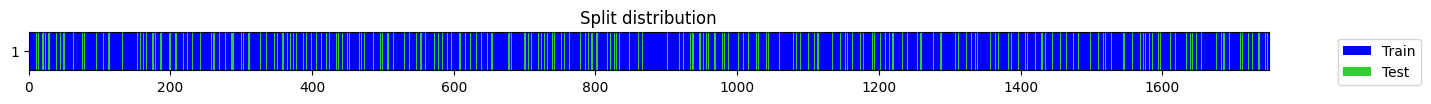

(#1750) [(TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(0)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(1)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(1)), (TSTensor(vars:16, len:8001, device=cpu, dtype=torch.float32), TensorCategory(1))] ...]

In [2]:
splits = get_splits(y_all, valid_size=.2, stratify=True, random_state=27, shuffle=True)
# splits = get_splits(y_all, valid_size =.2, stratify=True, random_state=23, shuffle=False)


tfms  = [None, [Categorize()]]
dsets = TSDatasets(X_all, y_all, tfms=tfms, splits=splits, inplace=True)
dsets

In [3]:
dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=160, batch_tfms=[TSStandardize(by_var=True)])

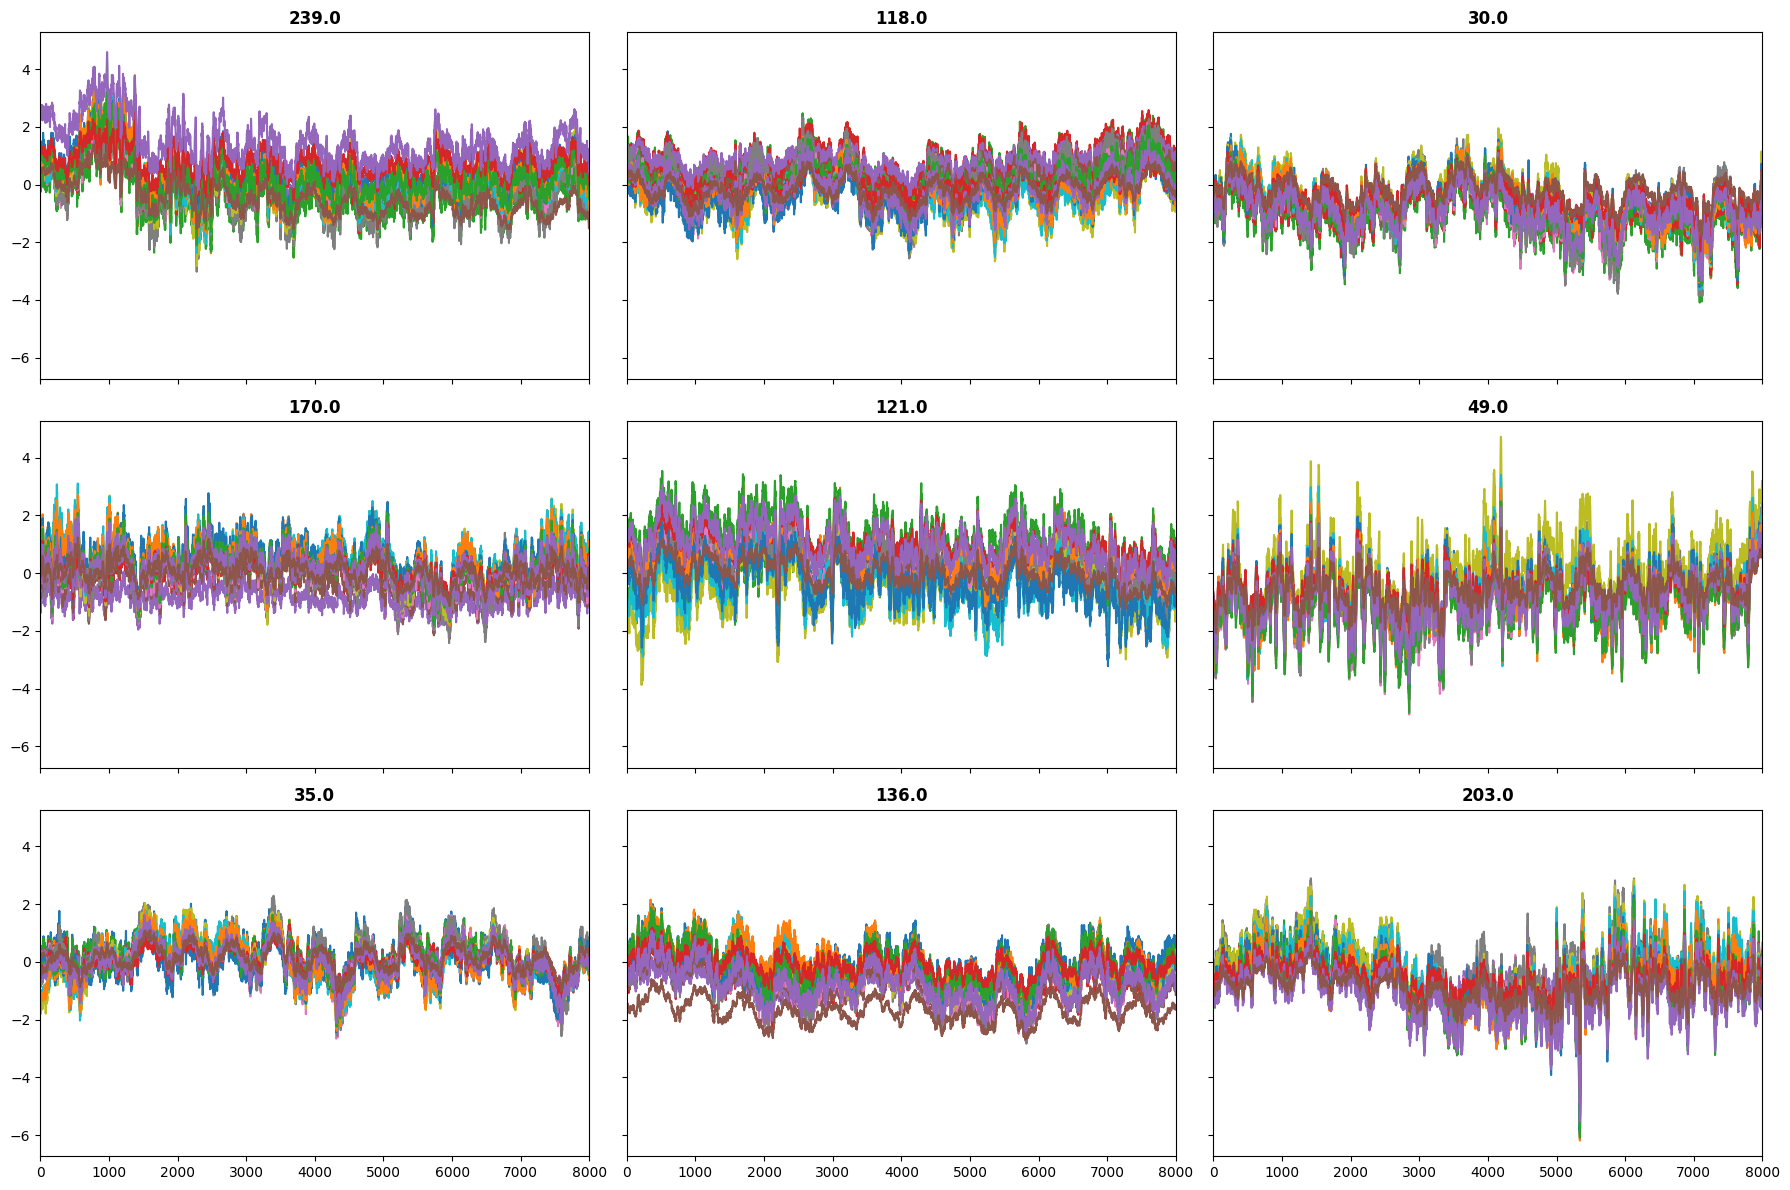

In [4]:
dls.show_batch(sharey=True)

In [5]:
# loss_func = CrossEntropyLossFlat(weight=class_weights)  # 使用设置的损失权重
model = InceptionTime(dls.vars, dls.c)
learn = Learner(dls, model, metrics=accuracy,  cbs=ShowGraphCallback2())
# learn.lr_find()
# learn.loss_func = loss_func  # 使用设置的损失函数
# learn.save('stage0')

SuggestedLRs(valley=0.0014454397605732083)

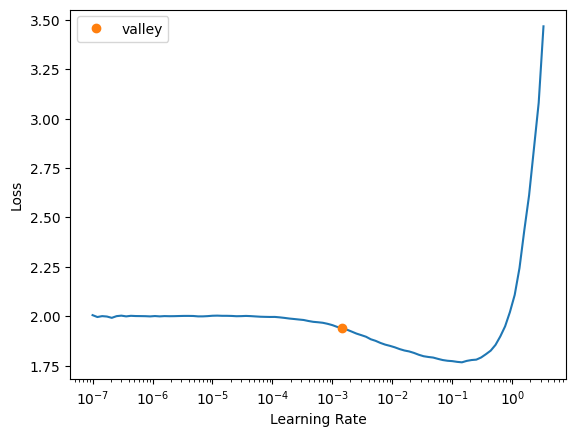

In [15]:

model = LSTM_FCNPlus(dls.vars, dls.c,dls.len)
learn = Learner(dls, model, metrics=accuracy,  cbs=ShowGraphCallback2())
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,time
0,5.617202,5.539428,0.005714,00:09
1,5.571589,5.542971,0.002857,00:04
2,5.526914,5.533958,0.005714,00:04
3,5.486190,5.493326,0.005714,00:04
4,5.446330,5.418890,0.005714,00:04
5,5.407034,5.332383,0.020000,00:04
6,5.367471,5.255805,0.031429,00:04
7,5.326140,5.200131,0.040000,00:04
8,5.283076,5.146789,0.048571,00:04
9,5.240615,5.091780,0.065714,00:04


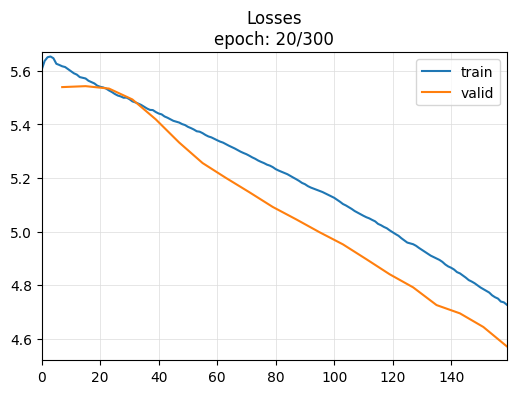

KeyboardInterrupt: 

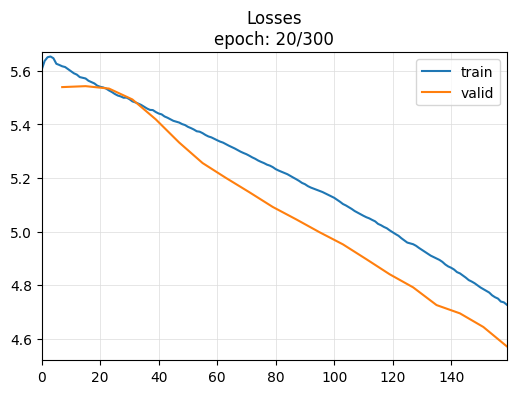

In [6]:
learn.fit_one_cycle(300, 8*1e-4)
# learn.export("2023_transformer_test.pkl")
# learn.export(fname='onlyexport/model_InceptionTime_20230421_2.pkl')
# learn.save('stage1')


In [25]:
learn.export(fname='onlyexport/model_InceptionTime.pkl')

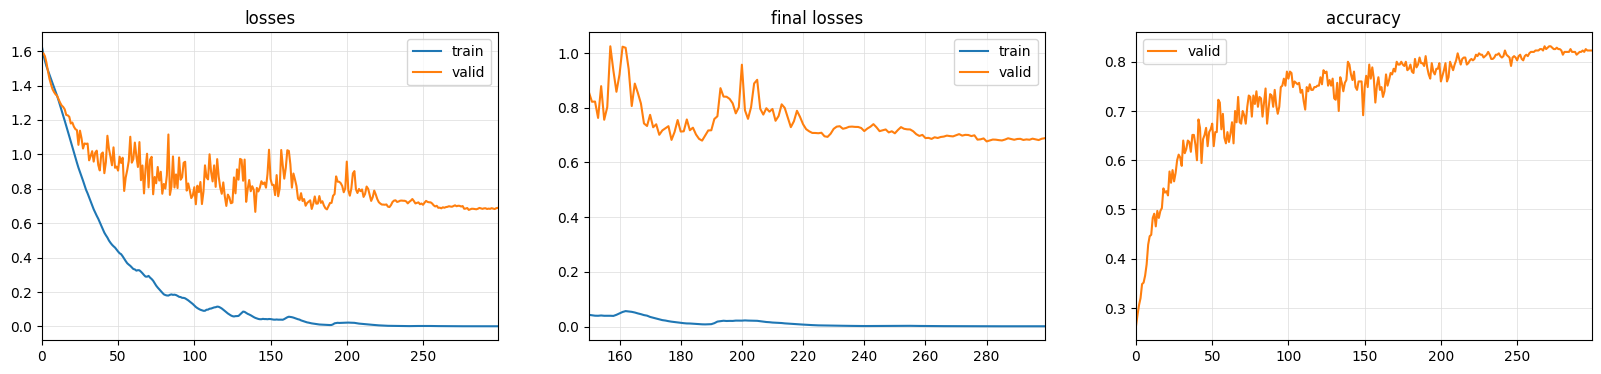

In [25]:
learn.recorder.plot_metrics()

In [26]:
valid_dl = dls.valid
valid_probas, valid_targets, valid_preds = learn.get_preds(dl=valid_dl, with_decoded=True)
valid_probas, valid_targets, valid_preds


(TensorBase([[1.6617e-03, 1.8076e-02, 1.4910e-02, 9.2551e-01, 3.9845e-02],
             [2.5622e-07, 1.0000e+00, 1.1745e-06, 4.7168e-08, 1.9013e-07],
             [8.9722e-04, 2.1725e-06, 7.7492e-06, 9.9909e-01, 7.8406e-07],
             ...,
             [8.7593e-01, 2.0002e-02, 7.4376e-02, 2.9531e-02, 1.5861e-04],
             [1.6228e-05, 2.8921e-05, 9.9988e-01, 1.7028e-05, 5.6718e-05],
             [1.9641e-01, 3.7262e-01, 7.9676e-03, 4.6359e-03, 4.1837e-01]]),
 tensor([3, 1, 3, 2, 2, 1, 0, 2, 1, 4, 0, 4, 4, 1, 1, 2, 3, 4, 3, 3, 2, 0, 3, 3,
         4, 0, 4, 1, 0, 3, 4, 3, 0, 0, 3, 4, 2, 2, 1, 4, 4, 4, 2, 3, 0, 0, 4, 4,
         0, 3, 1, 3, 2, 2, 2, 4, 0, 3, 4, 3, 4, 3, 4, 0, 1, 3, 0, 2, 1, 3, 2, 1,
         2, 4, 2, 1, 1, 4, 0, 0, 1, 4, 2, 3, 1, 0, 0, 1, 3, 4, 3, 0, 2, 2, 1, 3,
         0, 0, 1, 0, 3, 3, 1, 3, 0, 4, 2, 1, 3, 2, 2, 3, 3, 4, 4, 2, 3, 2, 4, 0,
         2, 2, 2, 1, 1, 1, 4, 3, 3, 1, 3, 4, 3, 4, 0, 3, 2, 1, 0, 1, 1, 1, 1, 4,
         3, 0, 4, 2, 4, 2, 2, 1, 4, 2, 4, 1,

2276

In [74]:
after_target_counts = valid_targets.numpy()
# after_target_counts = valid_preds.numpy()
after_target_counts = pd.DataFrame(after_target_counts)
after_target_counts = after_target_counts.value_counts()
target_total = after_target_counts.sum()
target0_ratio = np.float32(after_target_counts[0] / target_total)
target1_ratio = np.float32(after_target_counts[1] / target_total)

print(target0_ratio)
print(target1_ratio)
print(target_total)

0.6717624
0.32823756
5691


In [27]:
valid_preds

TensorBase([3, 1, 3, 0, 2, 3, 0, 2, 1, 4, 2, 4, 4, 4, 4, 2, 3, 4, 2, 3, 2, 0, 3,
            3, 4, 0, 4, 1, 0, 3, 4, 3, 0, 0, 3, 4, 2, 2, 1, 3, 4, 4, 2, 4, 4, 0,
            4, 2, 0, 3, 1, 2, 2, 2, 2, 4, 0, 3, 4, 3, 4, 3, 4, 0, 1, 3, 0, 2, 4,
            3, 2, 4, 2, 4, 2, 0, 1, 3, 0, 1, 1, 4, 2, 3, 1, 0, 0, 1, 3, 4, 4, 0,
            3, 2, 1, 3, 0, 0, 3, 0, 3, 3, 1, 3, 2, 4, 1, 1, 3, 2, 2, 0, 3, 4, 1,
            3, 3, 0, 4, 2, 2, 2, 2, 1, 1, 1, 4, 3, 3, 1, 3, 3, 3, 4, 1, 3, 2, 3,
            3, 1, 0, 1, 0, 4, 3, 0, 4, 3, 4, 2, 2, 1, 4, 2, 4, 1, 4, 2, 0, 4, 4,
            0, 4, 1, 1, 3, 0, 1, 0, 1, 4, 0, 3, 4, 0, 3, 0, 3, 0, 3, 2, 1, 0, 2,
            0, 2, 1, 0, 2, 0, 4, 3, 1, 2, 4, 0, 2, 3, 2, 3, 1, 0, 4, 2, 3, 0, 4,
            0, 4, 0, 1, 2, 2, 3, 0, 4, 1, 4, 0, 1, 2, 3, 2, 2, 1, 1, 0, 4, 4, 3,
            2, 1, 2, 4, 2, 0, 2, 2, 0, 3, 2, 3, 3, 0, 1, 4, 1, 3, 3, 2, 2, 2, 2,
            1, 4, 0, 1, 1, 0, 0, 2, 4, 3, 4, 0, 0, 3, 0, 1, 2, 1, 2, 1, 4, 1, 3,
            1, 0, 4, 0, 1, 0

In [28]:
acc = accuracy_multi(valid_preds, valid_targets)
acc

TensorBase(0.9229)

In [29]:
# (valid_targets == valid_preds).float().mean()
print((valid_targets == valid_preds).float().mean())

TensorBase(0.8229)


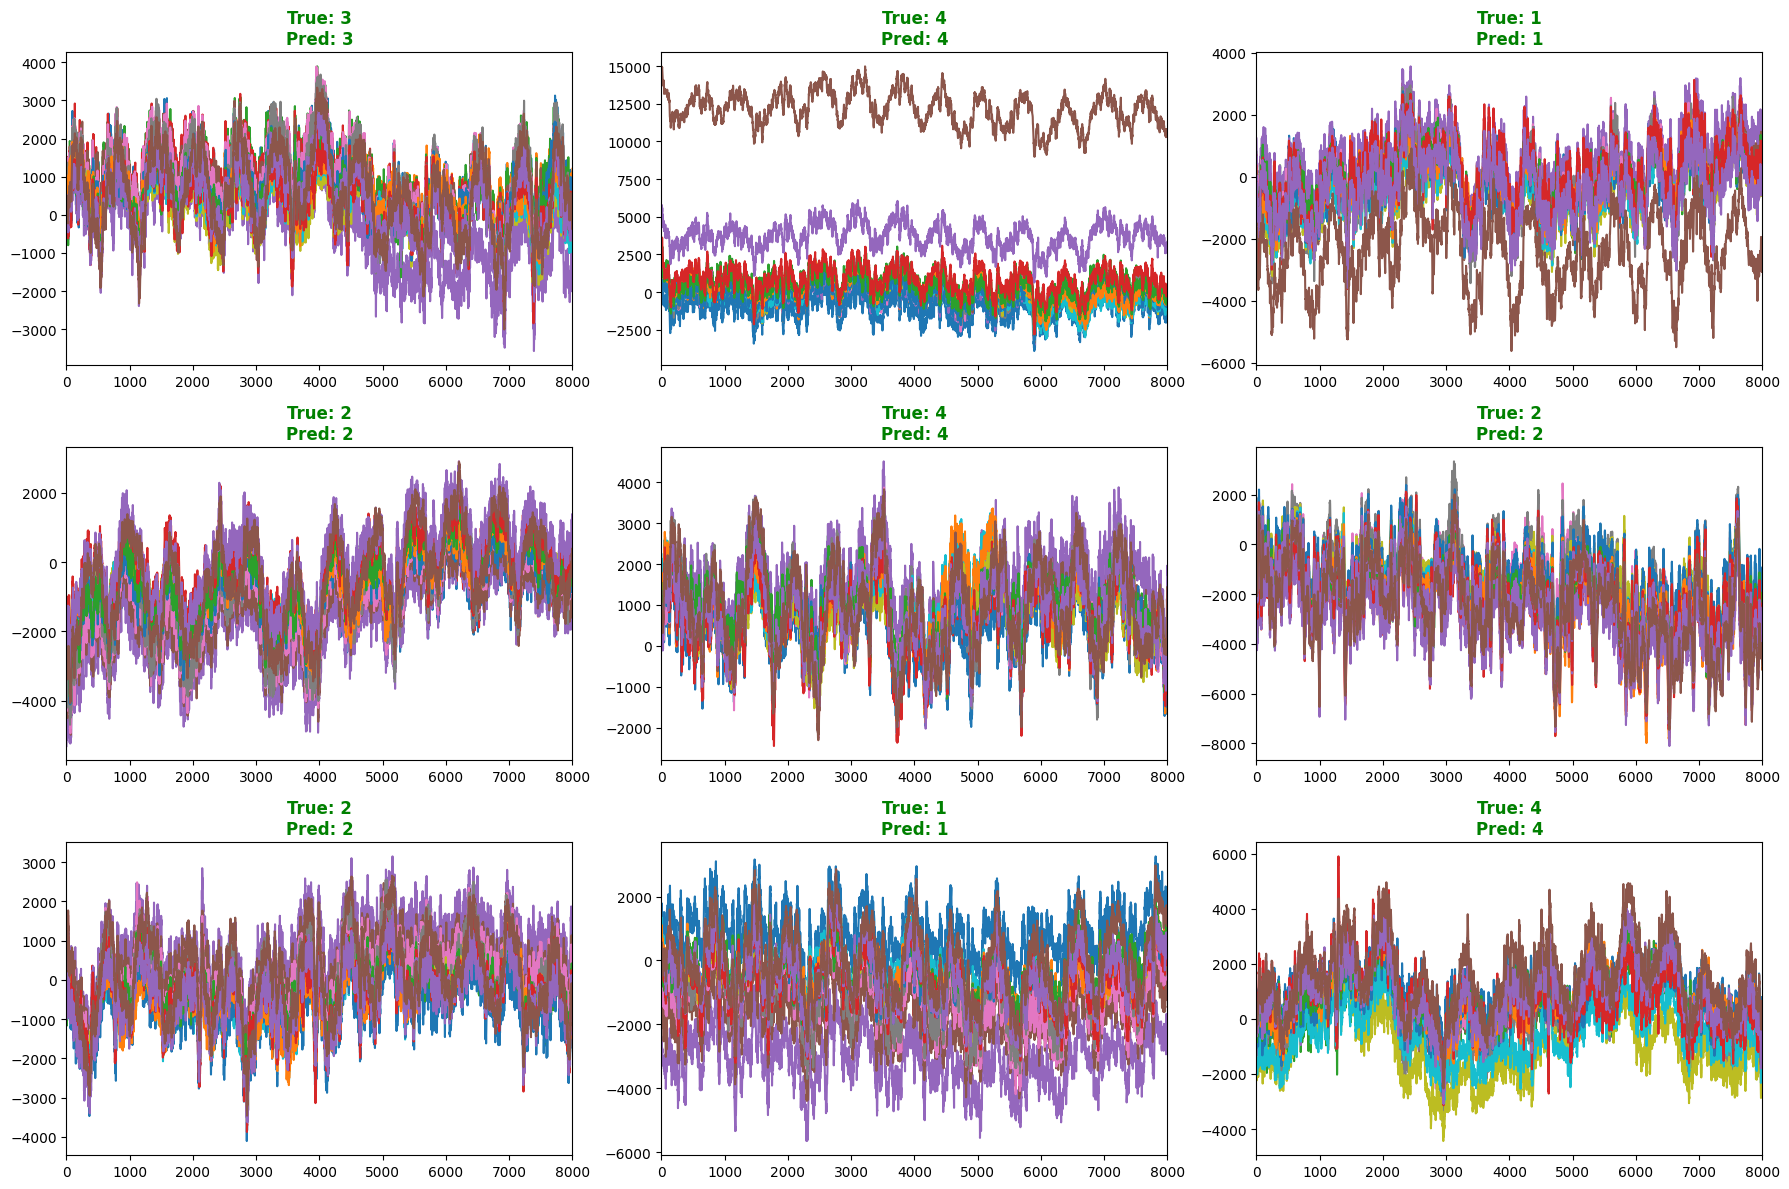

In [30]:
learn.show_results()

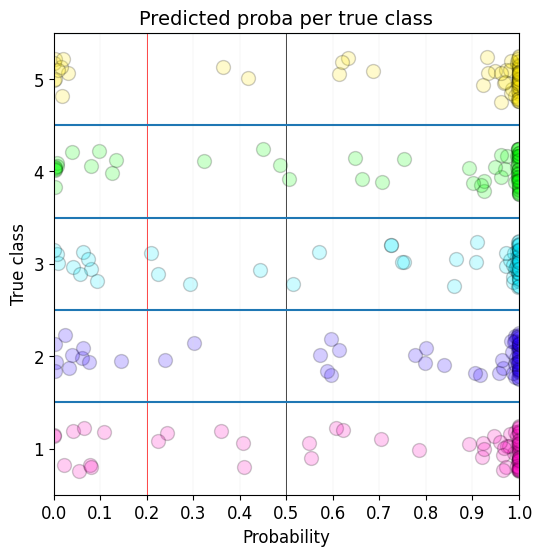

In [31]:
learn.show_probas()

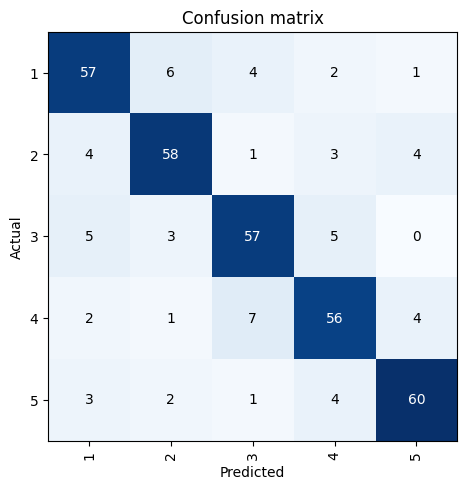

In [32]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()